In [2]:
import pandas as pd
import os
import csv
from scipy.special import softmax
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('../../data/results_pt/experiment_1b_raw/gpt-4o-mini_speaker_test_0_300_0_predicted_answers.csv')
df

,affect,goal,affect_valence,utterance,state,item,predicted_answer,parsed_answer
0,a,only,0,$50,$50,electric kettle,A:2,2
1,a,only,0,$50,$48,electric kettle,A:2,2
2,a,only,0,$50,$500,electric kettle,A:1,1
3,a,only,0,$50,$501,electric kettle,A:1,1
4,a,only,0,$50,$1000,electric kettle,A:1,1
...,...,...,...,...,...,...,...,...
2395,a,s_fuzzy,1,$9998,$999,watch,A:1,1
2396,a,s_fuzzy,1,$9998,$5000,watch,A:1,1
2397,a,s_fuzzy,1,$9998,$4998,watch,A:1,1
2398,a,s_fuzzy,1,$9998,$10000,watch,A:1,1


In [8]:
df["item"].unique()

array(['electric kettle', 'laptop', 'watch'], dtype=object)

In [4]:
df["utterance"] = df["utterance"].apply(lambda x: int(x.replace("$", "")))
df["state"] = df["state"].apply(lambda x: int(x.replace("$", "")))

In [15]:
len(df)
df

,affect,goal,affect_valence,utterance,state,item,predicted_answer,parsed_answer
0,a,only,0,50,50,electric kettle,A:2,2
1,a,only,0,50,48,electric kettle,A:2,2
2,a,only,0,50,500,electric kettle,A:1,1
3,a,only,0,50,501,electric kettle,A:1,1
4,a,only,0,50,1000,electric kettle,A:1,1
...,...,...,...,...,...,...,...,...
2395,a,s_fuzzy,1,9998,999,watch,A:1,1
2396,a,s_fuzzy,1,9998,5000,watch,A:1,1
2397,a,s_fuzzy,1,9998,4998,watch,A:1,1
2398,a,s_fuzzy,1,9998,10000,watch,A:1,1


In [5]:
# group by affect, goal, affect_valence, states so that we can softmax over the utterances
df_utterance_probs = (
    df
    .groupby(['affect', 'goal', 'affect_valence', 'state'])
    .apply(lambda x: pd.DataFrame({
        # 'affect': x['affect'].tolist(),
        # 'goal': x['goal'].tolist(),
        # 'affect_valence': x['affect_valence'].tolist(),
        'utterance': x['utterance'].tolist(),
        'utterance_prob': softmax(x['parsed_answer'])
    }))
    .reset_index(level=[0, 1, 2, 3])  # Reset only the grouping indices
)

/var/folders/fn/6ct_6l112376k8288ws7798m0000gn/T/ipykernel_40126/1233798684.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.DataFrame({


In [19]:
df_utterance_probs

,affect,goal,affect_valence,state,utterance,utterance_prob
0,a,only,0,48,50,0.067435
1,a,only,0,48,48,0.067435
2,a,only,0,48,500,0.024808
3,a,only,0,48,501,0.024808
4,a,only,0,48,1000,0.024808
...,...,...,...,...,...,...
25,only,s_fuzzy,0,10000,999,0.013638
26,only,s_fuzzy,0,10000,5000,0.013638
27,only,s_fuzzy,0,10000,4998,0.013638
28,only,s_fuzzy,0,10000,10000,0.273921


In [6]:
# categorize the predictions

def categorize_s_u_pair(row):
    state = row["state"]
    utterance = row["utterance"]
    if state == utterance:
        interpretation = "exact"
    elif abs(state - utterance) < 4:
        interpretation = "fuzzy"
    elif utterance > state:
        interpretation = "hyperbolic"
    else:
        interpretation = "other"

    return interpretation

In [ ]:
# def classify_condition(row):
#     if (row["affect_valence"] == 1) and (row["affect"] == "a"):
#         condition = "hyperbole_1"
#     elif (row["affect_valence"] == 0) and (row["affect"] == "a"):
#         condition = "hyperbole_0"
#     elif 

In [7]:
df_utterance_probs_categorized = df_utterance_probs.copy()
df_utterance_probs_categorized["interpretation"] = df_utterance_probs_categorized.apply(categorize_s_u_pair, axis=1)

In [8]:
df_utterance_probs_categorized

,affect,goal,affect_valence,state,utterance,utterance_prob,interpretation
0,a,only,0,48,50,0.067435,fuzzy
1,a,only,0,48,48,0.067435,exact
2,a,only,0,48,500,0.024808,hyperbolic
3,a,only,0,48,501,0.024808,hyperbolic
4,a,only,0,48,1000,0.024808,hyperbolic
...,...,...,...,...,...,...,...
25,only,s_fuzzy,0,10000,999,0.013638,other
26,only,s_fuzzy,0,10000,5000,0.013638,other
27,only,s_fuzzy,0,10000,4998,0.013638,other
28,only,s_fuzzy,0,10000,10000,0.273921,exact


Text(0.5, 0, 'Goal')

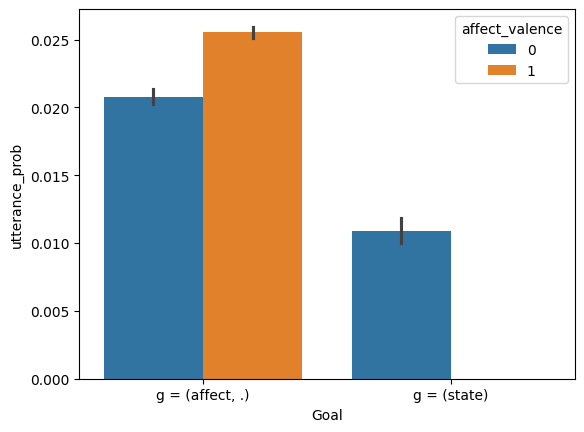

In [9]:
# plot the average probabilities of hyperbole s_u pairs, by affect

df_utterance_probs_categorized["interpretation"].value_counts()
df_utterance_probs_categorized_hyperbole = df_utterance_probs_categorized[df_utterance_probs_categorized["interpretation"] == "hyperbolic"]

sns.barplot(data=df_utterance_probs_categorized_hyperbole, x="affect", y="utterance_prob", hue="affect_valence")
# set x axis tick labels
plt.xticks(ticks=['a', 'only'], labels=["g = (affect, .)", "g = (state)"])
plt.xlabel("Goal")

In [10]:
df_utterance_probs_categorized["goal"] = df_utterance_probs_categorized["goal"].apply(lambda x: "-" if x == "only" else x)
df_utterance_probs_categorized["affect"] = df_utterance_probs_categorized["affect"].apply(lambda x: "-" if x == "only" else x)

/opt/anaconda3/envs/understanding_llms/lib/python3.10/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#1f77b4'` for the same effect.

  func(*plot_args, **plot_kwargs)
/opt/anaconda3/envs/understanding_llms/lib/python3.10/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#1f77b4'` for the same effect.

  func(*plot_args, **plot_kwargs)
/opt/anaconda3/envs/understanding_llms/lib/python3.10/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#1f77b4'` for the same effect.

  func(*plot_args, **plot_kwargs)
/opt/anaconda3/envs/understanding_llms/lib/python3.10/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is depr

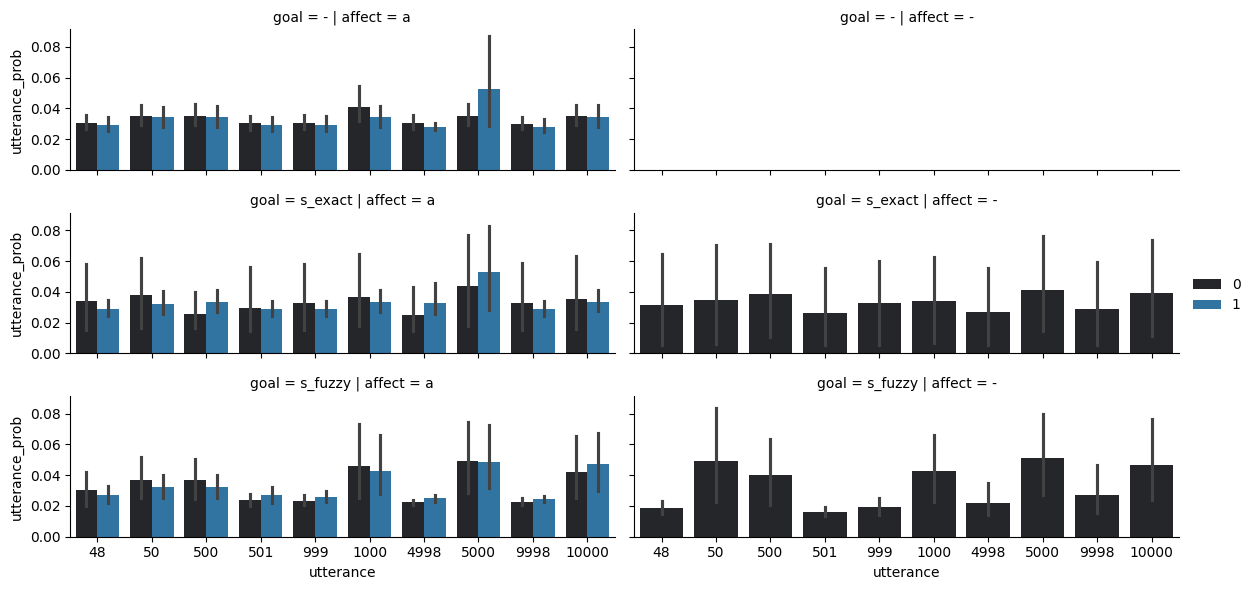

In [48]:
# plot probabilities of all types of utterances, by condition (affect as row, goal as column, affect_valence as hue)

# plot 
p = sns.FacetGrid(df_utterance_probs_categorized, col="affect", row="goal", height=2, aspect=3)
p.map_dataframe(sns.barplot, "utterance", "utterance_prob", hue="affect_valence")
# p.map(sns.barplot, "state", "results_1shot_probs", color="red", dodge=True)
# p.map(sns.barplot, "state", "results_2shot_probs", color="green", dodge=True)
# p.set_xticklabels(rotation=45)
p.add_legend() # title="Prompt", labels=["0-shot", "Goal 1-shot", "Example 2-shot"]
plt.show()

In [38]:
df["goal"] = df["goal"].apply(lambda x: "-" if x == "only" else x)
df["affect"] = df["affect"].apply(lambda x: "-" if x == "only" else x)

/var/folders/fn/6ct_6l112376k8288ws7798m0000gn/T/ipykernel_78889/3931010406.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.DataFrame({
/opt/anaconda3/envs/understanding_llms/lib/python3.10/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#1f77b4'` for the same effect.

  func(*plot_args, **plot_kwargs)
/opt/anaconda3/envs/understanding_llms/lib/python3.10/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#1f77b4'` for the same effect.

  func(*plot_args

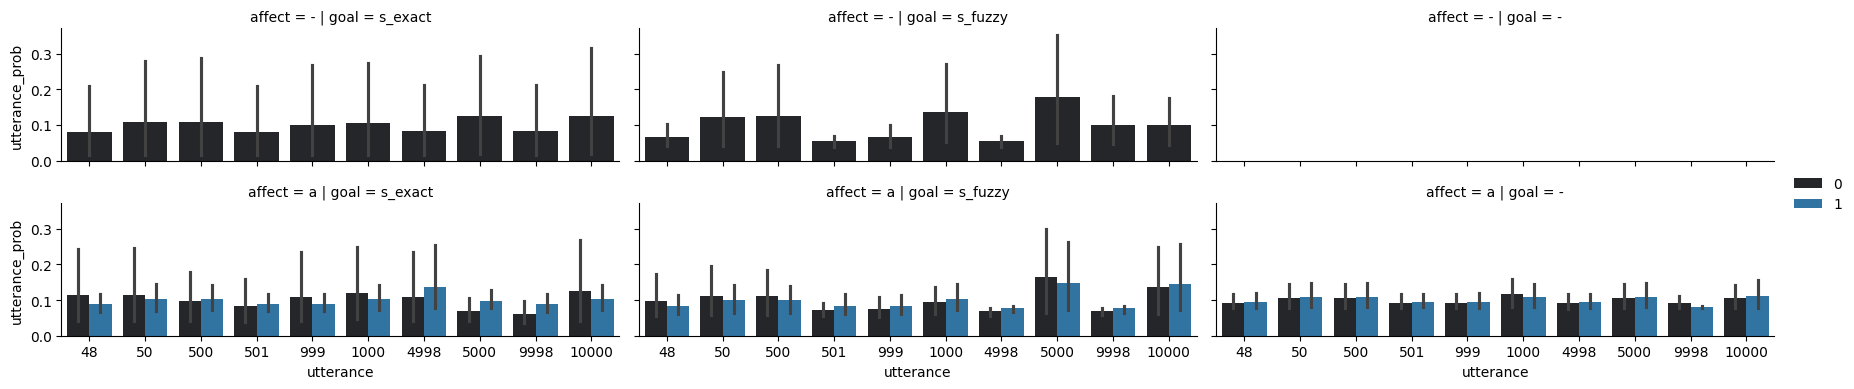

In [44]:
# now the same plot by item
# group by affect, goal, affect_valence, states so that we can softmax over the utterances
df_kettle = df[df["item"] == "electric kettle"]
df_utterance_probs_kettle = (
    df_kettle
    .groupby(['affect', 'goal', 'affect_valence', 'state'])
    .apply(lambda x: pd.DataFrame({
        # 'affect': x['affect'].tolist(),
        # 'goal': x['goal'].tolist(),
        # 'affect_valence': x['affect_valence'].tolist(),
        'utterance': x['utterance'].tolist(),
        'utterance_prob': softmax(x['parsed_answer'])
    }))
    .reset_index(level=[0, 1, 2, 3])  # Reset only the grouping indices
)

p_kettle = sns.FacetGrid(df_utterance_probs_kettle, col="goal", row="affect", height=2, aspect=3)
p_kettle.map_dataframe(sns.barplot, "utterance", "utterance_prob", hue="affect_valence")
# p.map(sns.barplot, "state", "results_1shot_probs", color="red", dodge=True)
# p.map(sns.barplot, "state", "results_2shot_probs", color="green", dodge=True)
# p.set_xticklabels(rotation=45)
p_kettle.add_legend() # title="Prompt", labels=["0-shot", "Goal 1-shot", "Example 2-shot"]
plt.show()

/var/folders/fn/6ct_6l112376k8288ws7798m0000gn/T/ipykernel_78889/2144813777.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.DataFrame({
/opt/anaconda3/envs/understanding_llms/lib/python3.10/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#1f77b4'` for the same effect.

  func(*plot_args, **plot_kwargs)
/opt/anaconda3/envs/understanding_llms/lib/python3.10/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#1f77b4'` for the same effect.

  func(*plot_args

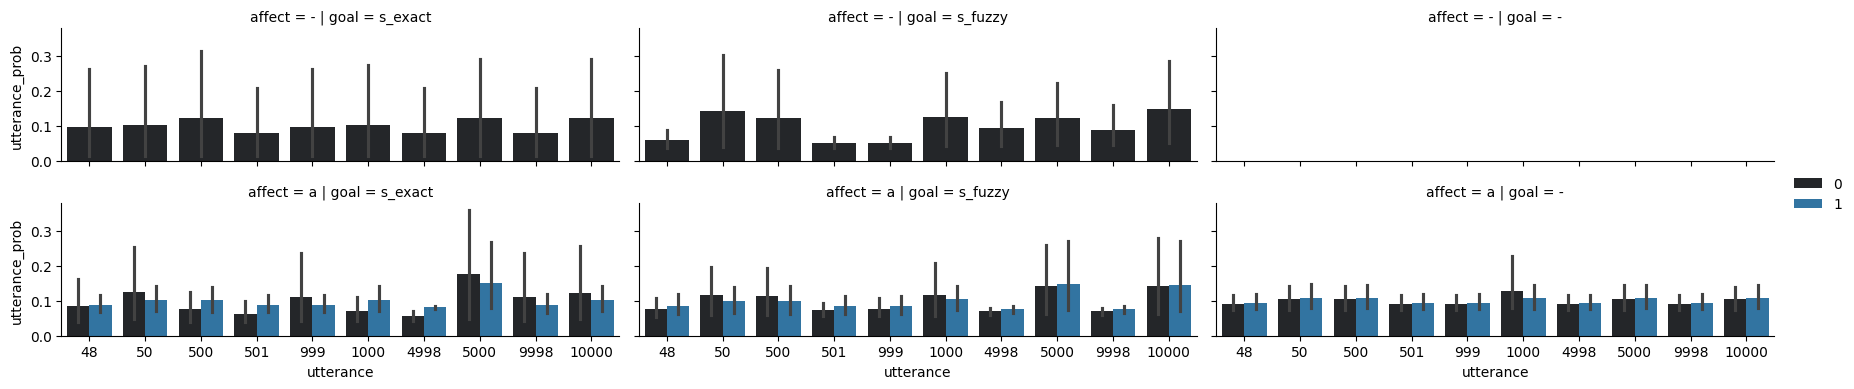

In [41]:
df_watch = df[df["item"] == "watch"]
df_utterance_probs_watch = (
    df_watch
    .groupby(['affect', 'goal', 'affect_valence', 'state'])
    .apply(lambda x: pd.DataFrame({
        # 'affect': x['affect'].tolist(),
        # 'goal': x['goal'].tolist(),
        # 'affect_valence': x['affect_valence'].tolist(),
        'utterance': x['utterance'].tolist(),
        'utterance_prob': softmax(x['parsed_answer'])
    }))
    .reset_index(level=[0, 1, 2, 3])  # Reset only the grouping indices
)

p_watch = sns.FacetGrid(df_utterance_probs_watch, col="goal", row="affect", height=2, aspect=3)
p_watch.map_dataframe(sns.barplot, "utterance", "utterance_prob", hue="affect_valence")
# p.map(sns.barplot, "state", "results_1shot_probs", color="red", dodge=True)
# p.map(sns.barplot, "state", "results_2shot_probs", color="green", dodge=True)
# p.set_xticklabels(rotation=45)
p_watch.add_legend() # title="Prompt", labels=["0-shot", "Goal 1-shot", "Example 2-shot"]
plt.show()

/var/folders/fn/6ct_6l112376k8288ws7798m0000gn/T/ipykernel_78889/1298286395.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.DataFrame({
/opt/anaconda3/envs/understanding_llms/lib/python3.10/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#1f77b4'` for the same effect.

  func(*plot_args, **plot_kwargs)
/opt/anaconda3/envs/understanding_llms/lib/python3.10/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#1f77b4'` for the same effect.

  func(*plot_args

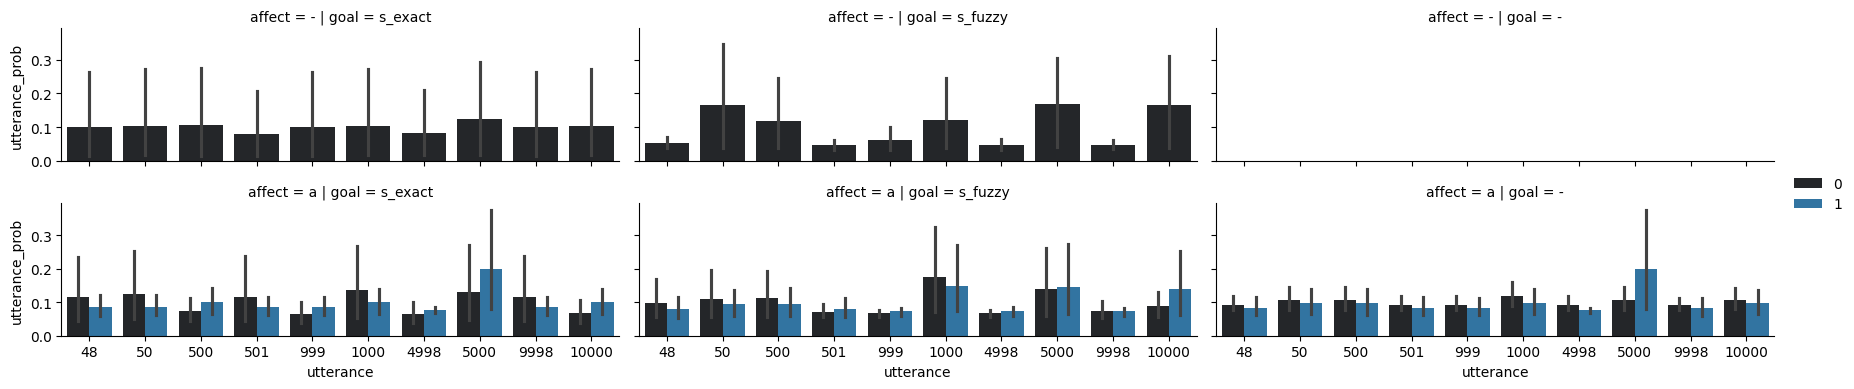

In [42]:
df_laptop = df[df["item"] == "laptop"]
df_utterance_probs_laptop = (
    df_laptop
    .groupby(['affect', 'goal', 'affect_valence', 'state'])
    .apply(lambda x: pd.DataFrame({
        # 'affect': x['affect'].tolist(),
        # 'goal': x['goal'].tolist(),
        # 'affect_valence': x['affect_valence'].tolist(),
        'utterance': x['utterance'].tolist(),
        'utterance_prob': softmax(x['parsed_answer'])
    }))
    .reset_index(level=[0, 1, 2, 3])  # Reset only the grouping indices
)

p_laptop = sns.FacetGrid(df_utterance_probs_laptop, col="goal", row="affect", height=2, aspect=3)
p_laptop.map_dataframe(sns.barplot, "utterance", "utterance_prob", hue="affect_valence")
# p.map(sns.barplot, "state", "results_1shot_probs", color="red", dodge=True)
# p.map(sns.barplot, "state", "results_2shot_probs", color="green", dodge=True)
# p.set_xticklabels(rotation=45)
p_laptop.add_legend() # title="Prompt", labels=["0-shot", "Goal 1-shot", "Example 2-shot"]
plt.show()

/opt/anaconda3/envs/understanding_llms/lib/python3.10/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#1f77b4'` for the same effect.

  func(*plot_args, **plot_kwargs)
/opt/anaconda3/envs/understanding_llms/lib/python3.10/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#1f77b4'` for the same effect.

  func(*plot_args, **plot_kwargs)


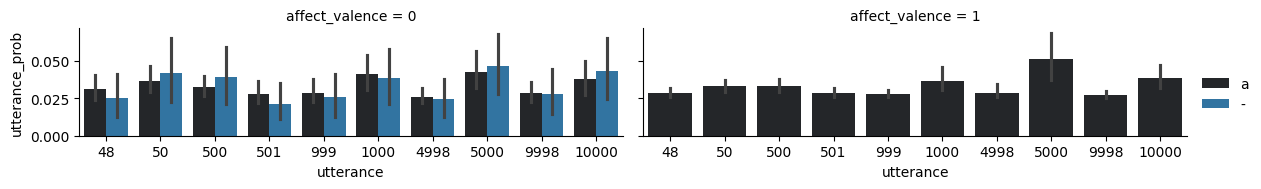

In [46]:
# look at the probs across goals

# plot 
p = sns.FacetGrid(df_utterance_probs_categorized, col="affect_valence", height=2, aspect=3)
p.map_dataframe(sns.barplot, "utterance", "utterance_prob", hue="affect")
# p.map(sns.barplot, "state", "results_1shot_probs", color="red", dodge=True)
# p.map(sns.barplot, "state", "results_2shot_probs", color="green", dodge=True)
# p.set_xticklabels(rotation=45)
p.add_legend() # title="Prompt", labels=["0-shot", "Goal 1-shot", "Example 2-shot"]
plt.show()

/opt/anaconda3/envs/understanding_llms/lib/python3.10/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#1f77b4'` for the same effect.

  func(*plot_args, **plot_kwargs)
/opt/anaconda3/envs/understanding_llms/lib/python3.10/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#1f77b4'` for the same effect.

  func(*plot_args, **plot_kwargs)
/opt/anaconda3/envs/understanding_llms/lib/python3.10/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#1f77b4'` for the same effect.

  func(*plot_args, **plot_kwargs)


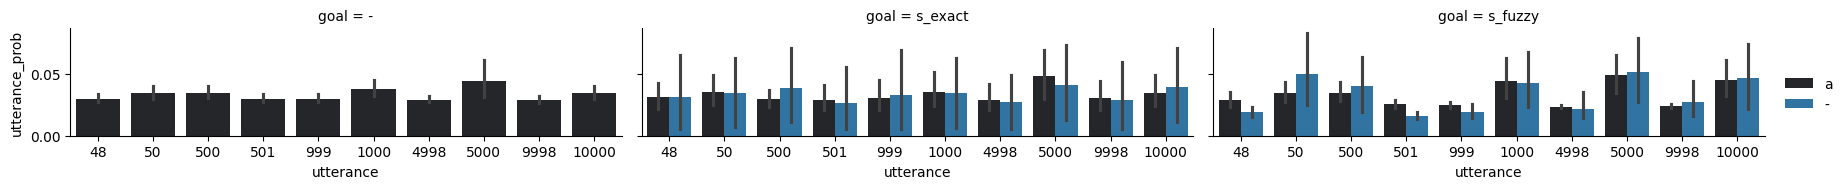

In [47]:
# look at the probs across affect goals

# plot 
p = sns.FacetGrid(df_utterance_probs_categorized, col="goal", height=2, aspect=3)
p.map_dataframe(sns.barplot, "utterance", "utterance_prob", hue="affect")
# p.map(sns.barplot, "state", "results_1shot_probs", color="red", dodge=True)
# p.map(sns.barplot, "state", "results_2shot_probs", color="green", dodge=True)
# p.set_xticklabels(rotation=45)
p.add_legend() # title="Prompt", labels=["0-shot", "Goal 1-shot", "Example 2-shot"]
plt.show()

In [22]:
# read all simulations of the speaker
df_5Sim = pd.read_csv('../../data/results_pt/experiment_1b_raw/gpt-4o-mini_speaker_test_0_300_0_iter4_predicted_answers.csv')
df_1Sim = pd.read_csv('../../data/results_pt/experiment_1b_raw/gpt-4o-mini_speaker_test_0_300_0_predicted_answers.csv')
df_allSim = pd.concat([df_1Sim, df_5Sim])

In [51]:
df_allSim

,affect,goal,affect_valence,utterance,state,item,predicted_answer,parsed_answer
0,a,only,0,$50,$50,electric kettle,A:2,2
1,a,only,0,$50,$48,electric kettle,A:2,2
2,a,only,0,$50,$500,electric kettle,A:1,1
3,a,only,0,$50,$501,electric kettle,A:1,1
4,a,only,0,$50,$1000,electric kettle,A:1,1
...,...,...,...,...,...,...,...,...
11995,a,s_fuzzy,1,$9998,$999,watch,A:1,1
11996,a,s_fuzzy,1,$9998,$5000,watch,A:1,1
11997,a,s_fuzzy,1,$9998,$4998,watch,A:1,1
11998,a,s_fuzzy,1,$9998,$10000,watch,A:1,1


In [23]:
df_allSim["utterance"] = df_allSim["utterance"].apply(lambda x: int(x.replace("$", "")))
df_allSim["state"] = df_allSim["state"].apply(lambda x: int(x.replace("$", "")))
df_allSim["goal"] = df_allSim["goal"].apply(lambda x: "-" if x == "only" else x)
df_allSim["affect"] = df_allSim["affect"].apply(lambda x: "-" if x == "only" else x)

df_allSim_utterance_probs = (
    df_allSim
    .groupby(['item', 'affect', 'goal', 'affect_valence', 'state'])
    .apply(lambda x: pd.DataFrame({
        # 'affect': x['affect'].tolist(),
        # 'goal': x['goal'].tolist(),
        # 'affect_valence': x['affect_valence'].tolist(),
        'utterance': x['utterance'].tolist(),
        'utterance_prob': softmax(x['parsed_answer'])
    }))
    .reset_index(level=[0, 1, 2, 3, 4])  # Reset only the grouping indices
)



/var/folders/fn/6ct_6l112376k8288ws7798m0000gn/T/ipykernel_40126/4083376000.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.DataFrame({


/opt/anaconda3/envs/understanding_llms/lib/python3.10/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#1f77b4'` for the same effect.

  func(*plot_args, **plot_kwargs)
/opt/anaconda3/envs/understanding_llms/lib/python3.10/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#1f77b4'` for the same effect.

  func(*plot_args, **plot_kwargs)
/opt/anaconda3/envs/understanding_llms/lib/python3.10/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#1f77b4'` for the same effect.

  func(*plot_args, **plot_kwargs)
/opt/anaconda3/envs/understanding_llms/lib/python3.10/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is depr

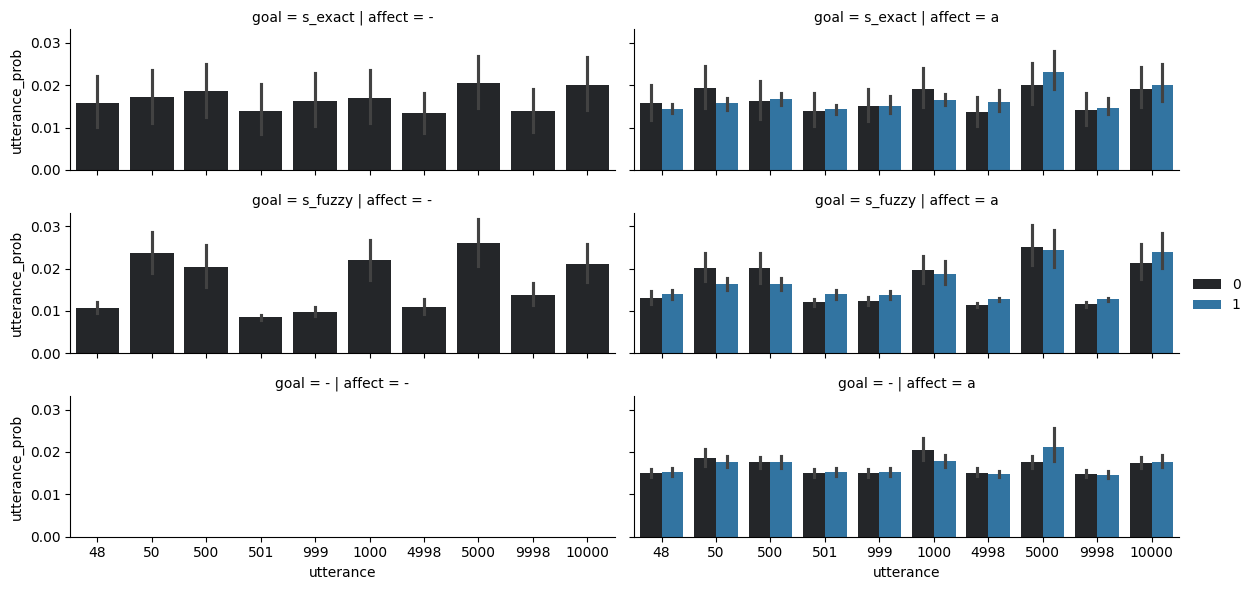

In [53]:
p = sns.FacetGrid(df_allSim_utterance_probs, col="affect", row="goal", height=2, aspect=3)
p.map_dataframe(sns.barplot, "utterance", "utterance_prob", hue="affect_valence")
# p.map(sns.barplot, "state", "results_1shot_probs", color="red", dodge=True)
# p.map(sns.barplot, "state", "results_2shot_probs", color="green", dodge=True)
# p.set_xticklabels(rotation=45)
p.add_legend() # title="Prompt", labels=["0-shot", "Goal 1-shot", "Example 2-shot"]
plt.show()

In [55]:
df_allSim_utterance_probs_mean = df_allSim_utterance_probs.groupby(
    ['item', 'affect', 'goal', 'affect_valence', 'state', 'utterance']
).mean('utterance_prob').reset_index()
df_allSim_utterance_probs_mean

,item,affect,goal,affect_valence,state,utterance,utterance_prob
0,electric kettle,-,s_exact,0,48,48,0.124443
1,electric kettle,-,s_exact,0,48,50,0.010708
2,electric kettle,-,s_exact,0,48,500,0.003939
3,electric kettle,-,s_exact,0,48,501,0.003939
4,electric kettle,-,s_exact,0,48,999,0.003939
...,...,...,...,...,...,...,...
2395,watch,a,s_fuzzy,1,10000,1000,0.014223
2396,watch,a,s_fuzzy,1,10000,4998,0.014223
2397,watch,a,s_fuzzy,1,10000,5000,0.014223
2398,watch,a,s_fuzzy,1,10000,9998,0.014223


In [56]:
# df_allSim_utterance_probs_mean.to_csv('../../data/results_pt/experiment_1b_raw/gpt-4o-mini_speaker_mean_probs.csv', index=False)

In [16]:
df_utterance_probs


,affect,goal,affect_valence,state,utterance,utterance_prob
0,a,only,0,48,50,0.067435
1,a,only,0,48,48,0.067435
2,a,only,0,48,500,0.024808
3,a,only,0,48,501,0.024808
4,a,only,0,48,1000,0.024808
...,...,...,...,...,...,...
25,only,s_fuzzy,0,10000,999,0.013638
26,only,s_fuzzy,0,10000,5000,0.013638
27,only,s_fuzzy,0,10000,4998,0.013638
28,only,s_fuzzy,0,10000,10000,0.273921


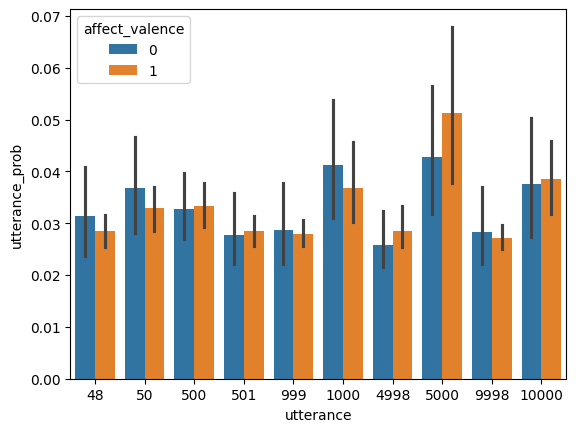

In [17]:
# plot 
# p = sns.FacetGrid(df_utterance_probs_categorized, col="affect", row="goal", height=2, aspect=3)
# p.map_dataframe(sns.barplot, "utterance", "utterance_prob", hue="affect_valence")
# df_utterance_probs_categorized_affect = df_utterance_probs[df_utterance_probs["affect"] != "only"]
p = sns.barplot(data=df_utterance_probs_categorized_affect, x="utterance", y="utterance_prob", hue="affect_valence")
plt.show()

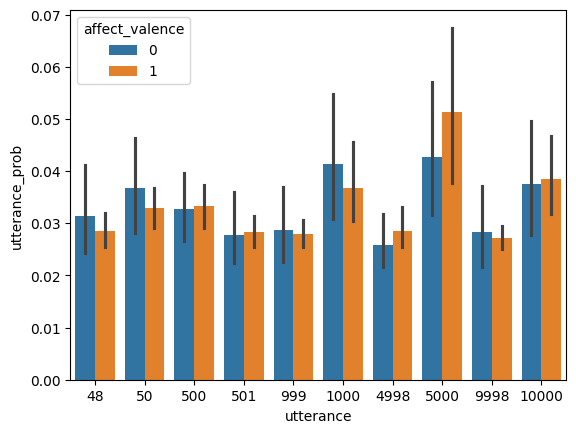

In [18]:
df_utterance_probs_categorized_affect = df_utterance_probs[df_utterance_probs["affect"] != "only"]
p = sns.barplot(data=df_utterance_probs_categorized_affect, x="utterance", y="utterance_prob", hue="affect_valence")
plt.show()

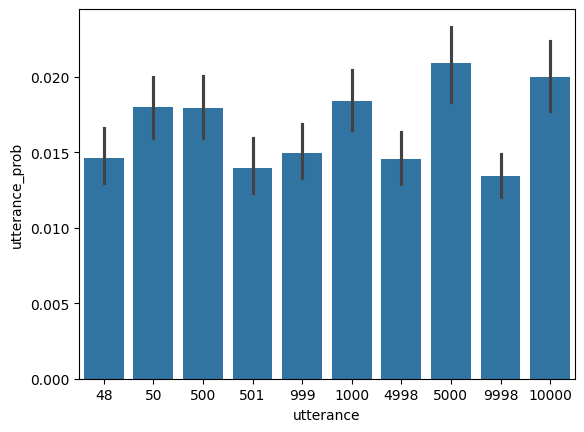

In [28]:
# plot utterances by item, across goals, to check inclusion of priors over prices implicitly 
df_utterance_kettle = df_allSim_utterance_probs[df_allSim_utterance_probs["item"] == "electric kettle"]
p = sns.barplot(data=df_utterance_kettle, x="utterance", y="utterance_prob")
plt.show()

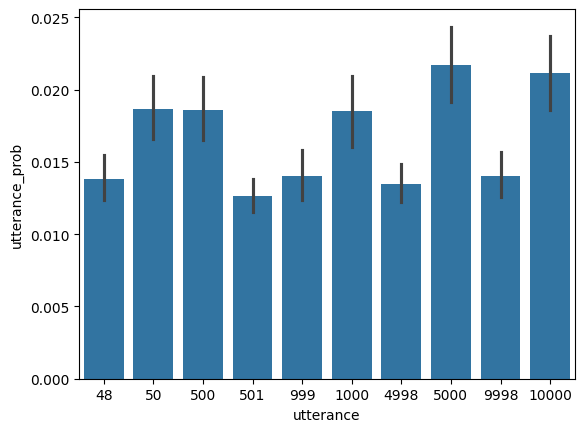

In [30]:
df_utterance_watch = df_allSim_utterance_probs[df_allSim_utterance_probs["item"] == "watch"]
p = sns.barplot(data=df_utterance_watch, x="utterance", y="utterance_prob")
plt.show()

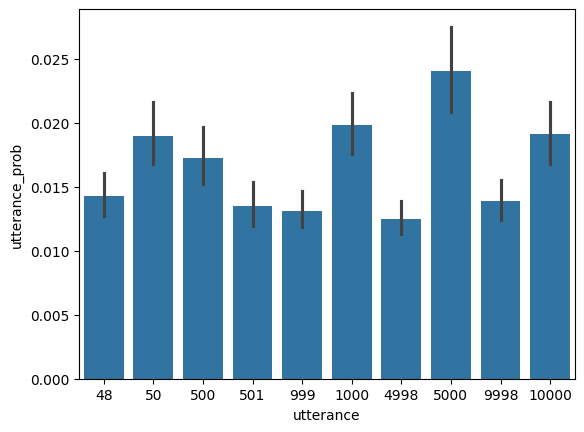

In [32]:
df_utterance_laptop = df_allSim_utterance_probs[df_allSim_utterance_probs["item"] == "laptop"]
p = sns.barplot(data=df_utterance_laptop, x="utterance", y="utterance_prob")
plt.show()

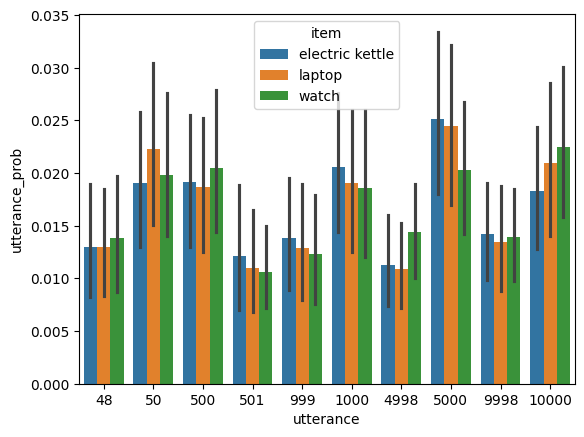

In [34]:
df_allSim_utterance_probs_nonaffect = df_allSim_utterance_probs[df_allSim_utterance_probs["affect"] == "-"]
p = sns.barplot(data=df_allSim_utterance_probs_nonaffect, x="utterance", y="utterance_prob", hue="item")
plt.show()